<a href="https://colab.research.google.com/github/mansimar20/IMAGE-RECOGNITION/blob/main/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YOLO -you only look once

In [ ]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
upload = files.upload()
file_name = list(upload.keys())[0]
print("Uploaded:", file_name)

Saving download cat.jpg to download cat.jpg
Uploaded: download cat.jpg


In [ ]:
model = YOLO('yolov8n.pt')

In [ ]:
results = model(file_name)
annotated = results[0].plot()


image 1/1 /content/download cat.jpg: 640x640 1 cat, 461.2ms
Speed: 19.2ms preprocess, 461.2ms inference, 40.0ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(224.5), np.float64(223.5), np.float64(-0.5))

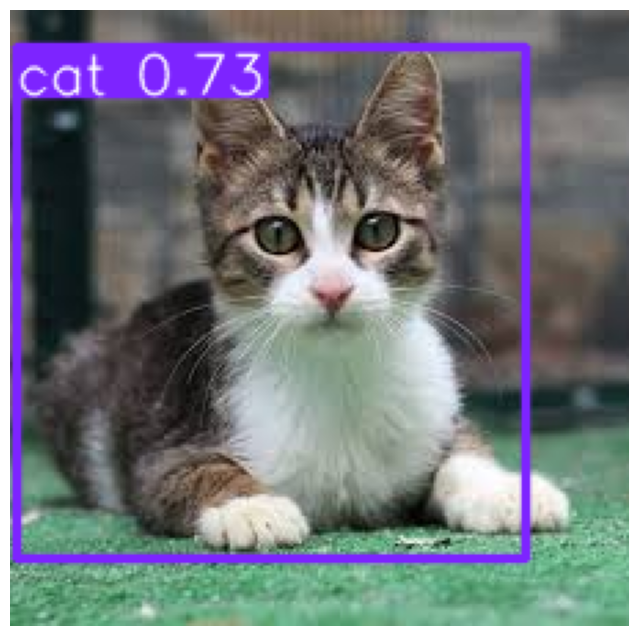

In [ ]:
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
plt.axis('off')

In [ ]:
upload = files.upload()
video_path=list(upload.keys())[0]
print("Uploaded:", video_path)

Saving 9.mpg to 9.mpg
Uploaded: 9.mpg


In [ ]:
output_path="output_detected.mp4"
cap=cv2.VideoCapture(video_path)
width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps=cap.get(cv2.CAP_PROP_FPS)or 25.0
fourcc=cv2.VideoWriter_fourcc(*'mp4v')
out=cv2.VideoWriter(output_path,fourcc,fps,(width,height))

frame_count=0
while True:
  ret,frame=cap.read()
  if not ret:
    break
  results=model(frame)
  annotated_frame=results[0].plot()
  out.write(annotated_frame)
  frame_count+=1
  if frame_count%100==0:
    print(f"Processed {frame_count} frames")
cap.release()
out.release()

print("Video Saved:",output_path)
files.download(output_path)

Streaming output truncated to the last 5000 lines.
0: 384x640 1 person, 1 kite, 145.5ms
Speed: 3.6ms preprocess, 145.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 145.7ms
Speed: 4.6ms preprocess, 145.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 159.3ms
Speed: 5.0ms preprocess, 159.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 144.5ms
Speed: 4.3ms preprocess, 144.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 kite, 142.9ms
Speed: 4.9ms preprocess, 142.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 kite, 142.8ms
Speed: 3.7ms preprocess, 142.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 140.8ms
Speed: 4.9ms preprocess, 140.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 k

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Captured: snapshot.jpg

image 1/1 /content/snapshot.jpg: 480x640 2 persons, 174.1ms
Speed: 2.0ms preprocess, 174.1ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


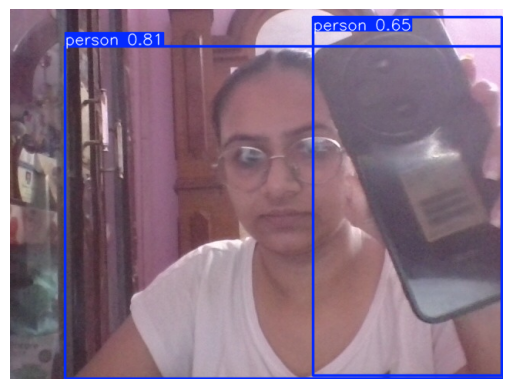

In [ ]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import output
from base64 import b64decode

# Load YOLO model
model = YOLO('yolov8n.pt')

def take_photo(filename='snapshot.jpg'):
    js = """
    async function takePhoto() {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 Capture';
      capture.style.fontSize = '20px';
      div.appendChild(capture);
      document.body.appendChild(div);

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.maxWidth = '100%';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize output window
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture button click
      await new Promise((resolve) => capture.onclick = resolve);

      // Draw video frame to canvas
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Stop the webcam
      stream.getTracks().forEach(track => track.stop());

      // Get image data
      const imgData = canvas.toDataURL('image/jpeg').split(',')[1];

      // Clean up UI
      div.remove();
      video.remove();

      return imgData;
    }
    takePhoto();
    """
    data = output.eval_js(js)
    with open(filename, "wb") as f:
        f.write(b64decode(data))
    return filename

# Capture photo
filename = take_photo('snapshot.jpg')
print("Captured:", filename)

# Run YOLO inference
results = model(filename)

# Display detection results
annotated = results[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Saving download cat.jpg to download cat (1).jpg

0: 640x640 1 cat, 253.8ms
Speed: 4.7ms preprocess, 253.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


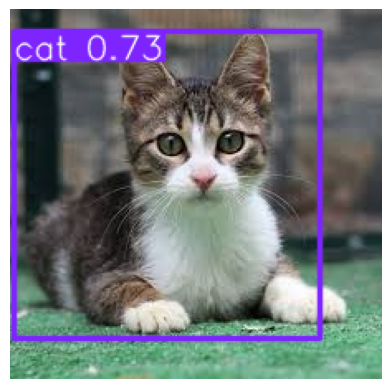

In [ ]:
from google.colab import files
import glob
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

for img_name in uploaded.keys():
    img = cv2.imread(img_name)
    results = model(img)
    annotated = results[0].plot()
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

In [ ]:
!curl -L "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip" -o coco128.zip
!unzip -q coco128.zip -d dataset
!ls dataset/coco128


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6819k  100 6819k    0     0  15.6M      0 --:--:-- --:--:-- --:--:-- 15.6M
replace dataset/coco128/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
images	labels	LICENSE  README.txt


In [ ]:
%%writefile dataset/coco128.yaml
path: dataset/coco128
train: images/train2017
val: images/val2017

nc: 80
names:
 0: person
 1: bicycle
 2: car
 3: motorcycle
 4: airplane
 5: bus
 6: train
 7: truck
 8: boat
 9: traffic light
 10: fire hydrant
 11: stop sign
 12: parking meter
 13: bench
 14: bird
 15: cat
 16: dog
 17: horse
 18: sheep
 19: cow
 20: elephant
 21: bear
 22: zebra
 23: giraffe
 24: backpack
 25: umbrella
 26: handbag
 27: tie
 28: suitcase
 29: frisbee
 30: skis
 31: snowboard
 32: sports ball
 33: kite
 34: baseball bat
 35: baseball glove
 36: skateboard
 37: surfboard
 38: tennis racket
 39: bottle
 40: wine glass
 41: cup
 42: fork
 43: knife
 44: spoon
 45: bowl
 46: banana
 47: apple
 48: sandwich
 49: orange
 50: broccoli
 51: carrot
 52: hot dog
 53: pizza
 54: donut
 55: cake
 56: chair
 57: couch
 58: potted plant
 59: bed
 60: dining table
 61: toilet
 62: tv
 63: laptop
 64: mouse
 65: remote
 66: keyboard
 67: cell phone
 68: microwave
 69: oven
 70: toaster
 71: sink
 72: refrigerator
 73: book
 74: clock
 75: vase
 76: scissors
 77: teddy bear
 78: hair drier
 79: toothbrush



Overwriting dataset/coco128.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="coco128.yaml",   # <-- just write this
    epochs=10,
    imgsz=640,
    project="YOLO_TRAINING",
    name="yolo8n_custom"
)


Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo8n_custom8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c063ffa69f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [ ]:
results=model.predict("/content/datasets/coco128/images/train2017/000000000009.jpg",save=True)


image 1/1 /content/datasets/coco128/images/train2017/000000000009.jpg: 480x640 3 bowls, 2 oranges, 1 broccoli, 1 hot dog, 294.1ms
Speed: 2.7ms preprocess, 294.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/YOLO_TRAINING/yolo8n_custom82


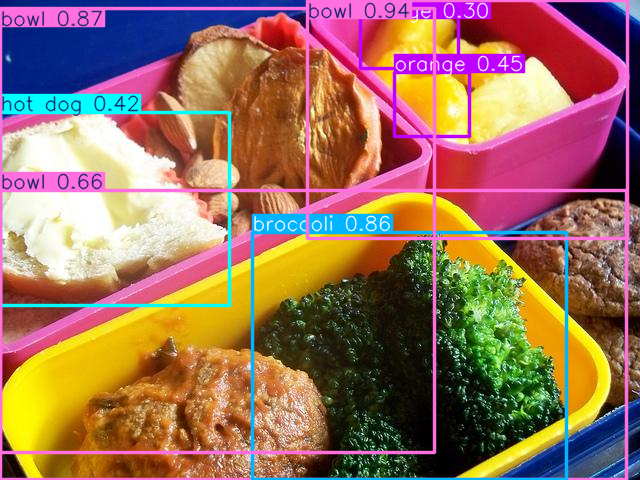

In [ ]:
results[0].show()

In [ ]:
!pip install streamlit==1.38.0 ultralytics==8.3.3 pyngrok==7.1.6 opencv-python-headless pillow pandas

In [ ]:
%%writefile app_streamlit.py
from ultralytics import YOLO
import streamlit as st
import numpy as np
from PIL import Image
import cv2,tempfile,os,glob
import pandas as pd
from pathlib import Path

st.set_page_config( page_title="Object Detection (DevTown)",layout="wide")
background_url = "https://i.ibb.co/FqVqvBBN/web-back.png"


st.markdown(
   f"""
   <style>
   .stApp {{
       background: url("{background_url}") no-repeat center center fixed;
       background-size: cover;
   }}
   /* Sidebar styling */
   section[data-testid="stSidebar"] {{
       background: rgba(0, 0, 0, 0.3);
       backdrop-filter: blur(10px);
       border-radius: 12px;
       padding: 10px;
   }}
   /* File uploader styling */
   div[data-testid="stFileUploader"] {{
       background: rgba(0, 0, 0, 0.3);
       backdrop-filter: blur(10px);
       border-radius: 12px;
       padding: 15px;
   }}
   /* DataFrame styling */
   .stDataFrame {{
       background: rgba(255, 255, 255, 0.85);
       border-radius: 12px;
       padding: 10px;
       box-shadow: 0 4px 10px rgba(0,0,0,0.3);
   }}
   /* Dark text */
   h1, h2, h3, h4, h5, h6, p, label, span, div {{
       color: #1a1a1a !important;
       font-weight: 500;
   }}
   </style>
   """,
   unsafe_allow_html=True
)

st.title("Object Detection (DevTown)")


uploaded_weights = st.sidebar.file_uploader("Upload custom .pt weights (optional)", type=["pt"])
conf = st.sidebar.slider("Confidence threshold", 0.0, 1.0, 0.25, 0.01)
img_size = st.sidebar.selectbox("Inference image size (px)", [320, 416, 640, 1280], index=2)


@st.cache_resource
def load_model(weights_path="yolov8n.pt"):
   return YOLO(weights_path)


def save_uploaded_file(uploaded_file, suffix=""):
   suffix = suffix if suffix else Path(uploaded_file.name).suffix
   tf = tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
   tf.write(uploaded_file.getbuffer())
   tf.flush()
   return tf.name


def annotate_and_table(results, model):
   res = results[0]
   try:
       plotted = res.plot()
       annotated = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
   except Exception:
       annotated = res.orig_img if hasattr(res, "orig_img") else None


   detections = []
   try:
       boxes = res.boxes
       if boxes is not None and len(boxes) > 0:
           for c, cf, box in zip(boxes.cls.cpu().numpy(), boxes.conf.cpu().numpy(), boxes.xyxy.cpu().numpy()):
               name = model.names[int(c)]
               detections.append({"class": name, "conf": float(cf), "bbox": [float(x) for x in box]})
   except:
       detections = []


   return annotated, pd.DataFrame(detections)


weights_to_load = "yolov8n.pt"
if uploaded_weights:
   weights_to_load = save_uploaded_file(uploaded_weights, suffix=".pt")
   st.sidebar.success("Using uploaded weights")


model = load_model(weights_to_load)


mode = st.radio("Select input", ["Image upload", "Video upload"])


if mode == "Image upload":
   uploaded = st.file_uploader("Upload image", type=["jpg","jpeg","png"])
   if uploaded:
       img = Image.open(uploaded).convert("RGB")
       st.image(img, caption="Input image")
       results = model.predict(np.array(img), conf=conf, imgsz=img_size)
       annotated, df = annotate_and_table(results, model)
       if annotated is not None:
           st.image(annotated, caption="Annotated")
       if not df.empty:
           st.dataframe(df)


elif mode == "Video upload":
   uploaded_vid = st.file_uploader("Upload video", type=["mp4","mov","avi","mkv"])
   if uploaded_vid:
       tmp = save_uploaded_file(uploaded_vid)
       st.video(tmp)
       project_dir = tempfile.mkdtemp()
       results = model.predict(source=tmp, conf=conf, imgsz=img_size, project=project_dir, name="run", save=True)
       try:
           out_dir = str(results[0].save_dir)
           vids = glob.glob(os.path.join(out_dir, "*"))
           vids = [v for v in vids if Path(v).suffix.lower() in [".mp4",".avi",".mov",".mkv"]]
           if vids:
               st.success("Annotated video")
               st.video(vids[0])
       except:
           st.warning("Could not display annotated video")






Overwriting app_streamlit.py


In [ ]:
from pyngrok import ngrok

# Set your auth token
NGROK_AUTH_TOKEN = "32h5LYuFCCKbjNTZuaiBUneBSqo_4RprfJwRbawQHuRJts5wh"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open tunnel to port 8501
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

# Run Streamlit app on port 8501
!streamlit run app_streamlit.py --server.port 8501 &

# Keep the process alive
import time
while True:
    time.sleep(60)


Public URL: NgrokTunnel: "https://0c44242eaf44.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.170.1.132:8501

2025-09-14 14:44:41.336 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_

0: 448x640 3 scissorss, 240.3ms
Speed: 9.0ms preprocess, 240.3ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)
2025-09-14 14:45:44.759 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_

0: 448x640 1 person, 176.5ms
Speed: 4.7ms preprocess, 176.5ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 6 persons, 183.8ms
Speed: 4.8ms preprocess, 183.8ms inference, 1.4ms postprocess per image at shap